In [1]:
import pickle
import numpy as np
with open('../structured_abstract_sections.pkl', 'rb') as f:
    normalized_sections = pickle.load(f)

sentences = []
indices = []
for normal_sect in normalized_sections:
    print(f'{normal_sect}: {len(normalized_sections[normal_sect])}')
    index = [len(sentences)]
    sentences += [text.lower() for text in normalized_sections[normal_sect]]
    index.append(len(sentences))
    indices.append(index)
    
labels = np.zeros(indices[-1][1], dtype=int)  # 創建一個與最大索引一致的 0 陣列

# 根據 indices 填充標籤
for i, (start, end) in enumerate(indices):
    labels[start:end] = i


methods: 1492
background: 215
results: 314
conclusions: 488
objective: 523


In [2]:
import torch
import numpy as np
import random

# 設置隨機種子
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # 確保所有 GPU 也使用相同種子
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False  # 避免非確定性算法

seed = 42
seed_everything(seed)

In [3]:
# embeddings.shape

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import numpy as np

class EmbeddingDataset(Dataset):
    def __init__(self, sentences, labels):
        labels = np.array(labels, dtype=np.longlong)

        self.sentences = sentences
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.sentences[idx], self.labels[idx]

In [5]:
# 2. 定義分類模型

from transformers import AutoTokenizer, AutoModel

class Classifier(nn.Module):
    def __init__(self, num_classes):
        super(Classifier, self).__init__()
        self.bert = AutoModel.from_pretrained("sentence-transformers/all-MiniLM-L6-v2")
        self.fc1 = nn.Linear(self.bert.config.hidden_size, 128)  # 隱藏層 128 維
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, num_classes)  # 輸出層

    def mean_pool(self, last_hidden_state, attention_mask):
        mask = attention_mask.unsqueeze(-1).type_as(last_hidden_state)  # [B,T,1]
        summed = (last_hidden_state * mask).sum(dim=1)                  # [B,H]
        counts = mask.sum(dim=1).clamp(min=1e-9)                        # [B,1]
        return summed / counts

    def forward(self, input_ids, attention_mask):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask, return_dict=True)
        sent = self.mean_pool(out.last_hidden_state, attention_mask)    
        x = self.fc1(sent)
        x = self.relu(x)
        x = self.fc2(x)
        return x  

In [6]:
# 3. 創建 Dataset & DataLoader
from tqdm import tqdm

tokenizer = AutoTokenizer.from_pretrained("sentence-transformers/all-MiniLM-L6-v2")

def train_model(train_loader, model, epochs=10, lr_enc=2e-5, lr_head=1e-3):
    criterion = nn.CrossEntropyLoss()
    device = "cuda"
    model.to(device)

    # 兩段學習率：encoder 小、分類頭大
    optimizer = torch.optim.AdamW([
        {"params": model.bert.parameters(), "lr": lr_enc},
        {"params": list(model.fc1.parameters()) + list(model.fc2.parameters()), "lr": lr_head},
    ], weight_decay=0.01)

    model.train()
    for epoch in range(1, epochs + 1):
        total_loss = 0.0
        for batch_sentences, batch_labels in train_loader:
            # 若 batch_sentences 已是 list[str]，不要 .tolist()
            enc = tokenizer(
                batch_sentences,
                padding=True,
                truncation=True,
                max_length=128,
                return_tensors="pt"
            )
            input_ids = enc["input_ids"].to(device)
            attention_mask = enc["attention_mask"].to(device)
            labels = torch.as_tensor(batch_labels, dtype=torch.long, device=device)

            optimizer.zero_grad()
            logits = model(input_ids, attention_mask)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * input_ids.size(0)

        print(f"Epoch {epoch}/{epochs} - Loss: {total_loss/len(train_loader.dataset):.4f}")

    return model

In [7]:
mapping = {
    -1: 'None',
    0:'methods',
    1:'background',
    2:'results',
    3:'conclusions',
    4:'objective',
}

In [27]:
import numpy as np
import torch
import torch.nn.functional as F
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

def evaluate_model(
    test_loader,
    model,
    num_classes,
    tokenizer,
    device=None,
    max_len=128,
    average='weighted',
    threshold=None,                  # e.g., 0.5；None 表示不拒判
    reject_policy='ignore'           # 'ignore' 或 'as_class'
):
    """
    reject_policy:
      - 'ignore': 排除被拒判的樣本再計分（最常見）
      - 'as_class': 把拒判視為類別 -1，與其他類別一起評分
    """
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval(); model.to(device)

    all_y, all_pred, all_prob = [], [], []

    with torch.no_grad():
        for texts, labels in test_loader:  # texts: list[str], labels: Tensor[B]
            enc = tokenizer(
                texts, padding=True, truncation=True,
                max_length=max_len, return_tensors="pt"
            )
            input_ids = enc["input_ids"].to(device)
            attention_mask = enc["attention_mask"].to(device)
            labels = labels.to(device).long()

            logits = model(input_ids, attention_mask)            # [B, C]
            probs  = F.softmax(logits, dim=1)                    # [B, C]
            conf, argmax = probs.max(dim=1)                      # [B], [B]

            if threshold is None:
                preds = argmax
            else:
                # 低於門檻的樣本 → -1（拒判）
                preds = torch.where(conf >= threshold, argmax, torch.full_like(argmax, -1))

            all_y.append(labels)
            all_pred.append(preds)
            all_prob.append(probs)

    y_true = torch.cat(all_y).cpu().numpy()
    y_pred = torch.cat(all_pred).cpu().numpy()
    prob   = torch.cat(all_prob).cpu().numpy()  # for ROC (one-vs-rest)

    # --- 評分 ---
    if threshold is not None and reject_policy == 'ignore':
        mask = (y_pred != -1)
        kept = mask.sum()
        if kept == 0:
            print("All predictions rejected under the current threshold.")
            return y_true, y_pred
        y_eval = y_true[mask]
        y_hat  = y_pred[mask]
        prob_eval = prob[mask]
        print(f"(Evaluated on {kept}/{len(y_true)} samples; {len(y_true)-kept} rejected)")
    else:
        # 將 -1 視為類別：不建議拿來和不拒判的情況直接比較
        y_eval = y_true
        y_hat  = y_pred
        prob_eval = prob  # ROC 仍用原本 C 類的機率

    # Classification metrics（多分類）
    acc = (y_hat == y_eval).mean()
    prec = precision_score(y_eval, y_hat, average=average, zero_division=0)
    rec  = recall_score(y_eval, y_hat, average=average, zero_division=0)
    f1   = f1_score(y_eval, y_hat, average=average, zero_division=0)

    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")

    # classification_report：若有拒判且 policy='as_class'，把 -1 列入 labels 以免警告
    if threshold is not None and reject_policy == 'as_class':
        labels_for_report = list(range(num_classes)) + [-1]
        target_names = [f"Class {i}" for i in range(num_classes)] + ["Rejected(-1)"]
        print(classification_report(y_eval, y_hat, labels=labels_for_report,
                                    target_names=target_names, digits=4, zero_division=0))
    else:
        
        print(classification_report(y_eval, y_hat, digits=4, zero_division=0))

    # --- 新增：每類別 P/R/F1（per-class） ---
    # 若不把拒判當成類別，僅對 0..C-1 計算；若要把拒判當成一類，請改成 + [-1]
    labels_for_metrics = list(range(num_classes))
    prec_cls = precision_score(y_eval, y_hat, labels=labels_for_metrics, average=None, zero_division=0)
    rec_cls  = recall_score(   y_eval, y_hat, labels=labels_for_metrics, average=None, zero_division=0)
    f1_cls   = f1_score(       y_eval, y_hat, labels=labels_for_metrics, average=None, zero_division=0)

    print("\nPer-class metrics:")
    for idx, (p, r, f1c) in enumerate(zip(prec_cls, rec_cls, f1_cls)):
        cls_id = labels_for_metrics[idx]
        name = (mapping.get(cls_id) if mapping else f"Class {cls_id}")
        print(f"{name:>15s} | P={p:.4f}  R={r:.4f}  F1={f1c:.4f}")

        

    # --- ROC（one-vs-rest，只對真實類別 0..C-1；拒判不影響這裡的定義） ---
    from sklearn.preprocessing import label_binarize
    y_bin = label_binarize(y_eval, classes=np.arange(num_classes))
    fpr, tpr, roc_auc = {}, {}, {}
    for i in range(num_classes):
        fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], prob_eval[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    plt.figure(figsize=(8, 6))
    for i in range(num_classes):
        plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC={roc_auc[i]:.2f})")
    plt.plot([0,1],[0,1],"k--")
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title("Multi-class ROC Curve"); plt.legend(); plt.show()

    return y_true, y_pred


## test

In [9]:
from collections import defaultdict
from tqdm import tqdm
import torch
from torch.utils.data import Dataset, DataLoader
from sentence_transformers import SentenceTransformer, InputExample, losses
import pandas



In [10]:
from sklearn.model_selection import train_test_split

num_samples = len(sentences)
num_classes = 5

train_sentences, test_sentences, train_labels, test_labels = train_test_split(
    sentences, labels, test_size=0.1, random_state=42, shuffle=True, stratify=labels
)

# 7. 創建 PyTorch Dataset & DataLoader
train_dataset = EmbeddingDataset(train_sentences, train_labels)
test_dataset = EmbeddingDataset(test_sentences, test_labels)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


# 8. 初始化並訓練模型
model = Classifier(num_classes)
trained_model = train_model(train_loader, model)

# 9. 測試模型
# labels, predictions_supervise = evaluate_model(test_loader, trained_model, num_classes, threshold=0.4, average='weighted')


Epoch 1/10 - Loss: 0.6823
Epoch 2/10 - Loss: 0.2883
Epoch 3/10 - Loss: 0.1982
Epoch 4/10 - Loss: 0.1430
Epoch 5/10 - Loss: 0.1059
Epoch 6/10 - Loss: 0.0700
Epoch 7/10 - Loss: 0.0582
Epoch 8/10 - Loss: 0.0388
Epoch 9/10 - Loss: 0.0348
Epoch 10/10 - Loss: 0.0311


(Evaluated on 304/304 samples; 0 rejected)
Accuracy : 0.9079
Precision: 0.9144
Recall   : 0.9079
F1-score : 0.9082
              precision    recall  f1-score   support

           0     0.9404    0.9467    0.9435       150
           1     0.6897    0.9091    0.7843        22
           2     0.8571    0.7742    0.8136        31
           3     0.9057    0.9796    0.9412        49
           4     0.9767    0.8077    0.8842        52

    accuracy                         0.9079       304
   macro avg     0.8739    0.8834    0.8734       304
weighted avg     0.9144    0.9079    0.9082       304


Per-class metrics:
        methods | P=0.9404  R=0.9467  F1=0.9435
     background | P=0.6897  R=0.9091  F1=0.7843
        results | P=0.8571  R=0.7742  F1=0.8136
    conclusions | P=0.9057  R=0.9796  F1=0.9412
      objective | P=0.9767  R=0.8077  F1=0.8842


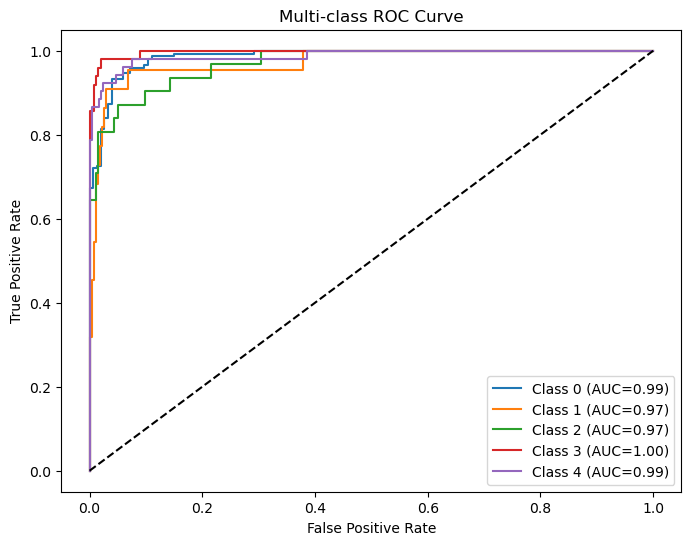

In [31]:
# 9. 測試模型
labels, predictions_supervise = evaluate_model(test_loader, trained_model, num_classes, tokenizer, threshold=0.4, average='weighted')

## val

In [ ]:
from collections import defaultdict
from tqdm import tqdm
import torch
from torch.utils.data import Dataset, DataLoader
from sentence_transformers import SentenceTransformer, InputExample, losses
import pandas

fine_tuned_model = SentenceTransformer("models/fine_tuned_sentence_bert_model_ContrastiveLoss_val_lower")

# 測試新模型
embeddings = fine_tuned_model.encode(sentences)


epoch 0:


100%|██████████| 76/76 [00:00<00:00, 814.48it/s]


Epoch 1/10, Loss: 55.2972
epoch 1:


100%|██████████| 76/76 [00:00<00:00, 838.08it/s]


Epoch 2/10, Loss: 4.6147
epoch 2:


...

Epoch 8/10, Loss: 0.1122
epoch 8:


100%|██████████| 76/76 [00:00<00:00, 832.61it/s]


Epoch 9/10, Loss: 0.0884
epoch 9:


100%|██████████| 76/76 [00:00<00:00, 812.90it/s]


Epoch 10/10, Loss: 0.0716
Precision: 0.9441
Recall: 0.9441
F1-score: 0.9441
Accuracy: 0.9441


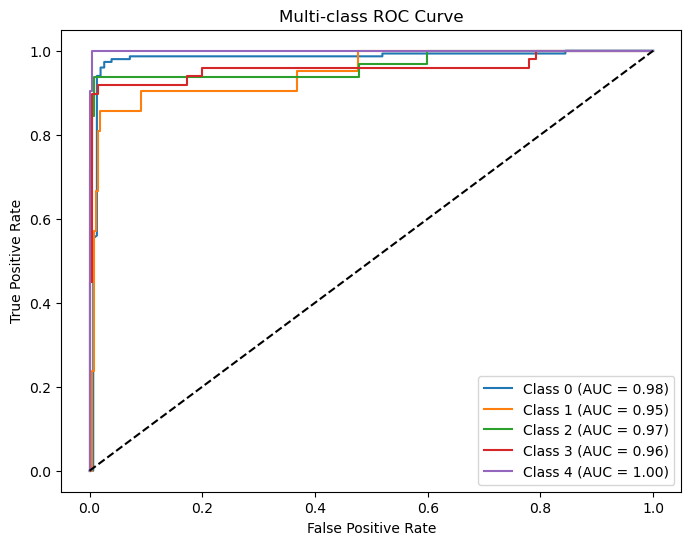

(0.944078947368421, 0.944078947368421, 0.944078947368421, 0.944078947368421)

In [ ]:
from sklearn.model_selection import train_test_split

num_samples = embeddings.shape[0]
embedding_dim = embeddings.shape[1]
num_classes = 5
threshold = 0.4

train_val_embeddings, test_embeddings, train_val_labels, test_labels = train_test_split(
    embeddings, labels, test_size=0.1, random_state=42, shuffle=True, stratify=labels
)

train_embeddings, val_embeddings, train_labels, val_labels = train_test_split(
    train_val_embeddings, train_val_labels, test_size=1/9, random_state=42, shuffle=True, stratify=train_val_labels
)

# 7. 創建 PyTorch Dataset & DataLoader
train_dataset = EmbeddingDataset(train_embeddings, train_labels)
val_dataset = EmbeddingDataset(val_embeddings, val_labels)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)


# 8. 初始化並訓練模型
model = Classifier(embedding_dim, num_classes)
trained_model = train_model(train_loader, model)

# 9. 測試模型
evaluate_model(val_loader, trained_model, num_classes, threshold, 'micro')


## Save whole

In [ ]:
from collections import defaultdict
from tqdm import tqdm
import torch
from torch.utils.data import Dataset, DataLoader
from sentence_transformers import SentenceTransformer, InputExample, losses
import pandas

fine_tuned_model = SentenceTransformer("models/fine_tuned_sentence_bert_model_ContrastiveLoss_lower")

# 測試新模型
embeddings = fine_tuned_model.encode(sentences)


In [ ]:
fine_tuned_model = SentenceTransformer("models/fine_tuned_sentence_bert_model_ContrastiveLoss_lower")
# 測試新模型
embeddings = fine_tuned_model.encode(sentences)


epoch 0:


100%|██████████| 95/95 [00:00<00:00, 828.10it/s]


Epoch 1/10, Loss: 65.1999
epoch 1:


100%|██████████| 95/95 [00:00<00:00, 867.83it/s]


Epoch 2/10, Loss: 4.8169
epoch 2:


...

Epoch 8/10, Loss: 0.1080
epoch 8:


100%|██████████| 95/95 [00:00<00:00, 727.13it/s]


Epoch 9/10, Loss: 0.0847
epoch 9:


100%|██████████| 95/95 [00:00<00:00, 754.22it/s]

Epoch 10/10, Loss: 0.0681


In [ ]:

dataset = EmbeddingDataset(embeddings, labels)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

model = Classifier(embedding_dim, num_classes)
trained_model = train_model(loader, model)

torch.save(model, "classifier_model_lower.pth")  # 或者用 .pt
